In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np

# ==============================================================================
# TAHAP 2: MEMUAT DATASET
# ==============================================================================
print("Memuat data dari Google Drive...")

# ⚠️ PENTING: Ubah path ini sesuai dengan lokasi file CSV-mu di Google Drive!
# Contoh: Jika file ada di folder "Magang_HCI", path-nya jadi '/content/drive/MyDrive/Magang_HCI/application_train.csv'
file_path = '/content/drive/MyDrive/Data Project/Rakamin Home kredit/application_train.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✅ Data berhasil dimuat! Ukuran awal: {df.shape[0]} baris, {df.shape[1]} kolom.\n")
except FileNotFoundError:
    print("❌ ERROR: File tidak ditemukan. Pastikan path (jalur file) di atas sudah benar.")
    raise # Menghentikan program jika file tidak ada

Memuat data dari Google Drive...
✅ Data berhasil dimuat! Ukuran awal: 307511 baris, 122 kolom.



**PROSES DATA CLEANSING**

In [3]:
# ==============================================================================
# TAHAP 3: PROSES DATA CLEANSING TERSTRUKTUR
# ==============================================================================
# 1. Deduplikasi (Menghapus baris ganda berdasarkan SK_ID_CURR)
awal_baris = df.shape[0]
df = df.drop_duplicates(subset=['SK_ID_CURR'])
print(f"[1] DEDUPLIKASI:")
print(f"    -> Ditemukan dan dihapus {awal_baris - df.shape[0]} baris duplikat.\n")

# print(f"1. Deduplikasi selesai. (Menghapus {awal_baris - df.shape[0]} baris duplikat)")

[1] DEDUPLIKASI:
    -> Ditemukan dan dihapus 0 baris duplikat.



In [4]:
# ==============================================================================
# 2. DROPPING COLUMNS WITH > 60% MISSING VALUES
# ==============================================================================
missing_percentages = df.isnull().mean()
columns_to_drop = missing_percentages[missing_percentages > 0.6].index

print(f"[2] DROP EMPTY COLUMNS (>60%):")

if len(columns_to_drop) > 0:
    print(f"    -> Found {len(columns_to_drop)} columns with > 60% missing data:")

    # Print column names and their missing percentages one by one
    for col in columns_to_drop:
        persentase = missing_percentages[col] * 100
        print(f"       - Dropped: '{col}' (Missing: {persentase:.2f}%)")

    # Execute column removal from dataframe
    df = df.drop(columns=columns_to_drop)
    print("    -> All above columns have been successfully removed from the dataframe.\n")
else:
    print("    -> No columns with > 60% missing data. Safe.\n")

[2] DROP EMPTY COLUMNS (>60%):
    -> Found 17 columns with > 60% missing data:
       - Dropped: 'OWN_CAR_AGE' (Missing: 65.99%)
       - Dropped: 'YEARS_BUILD_AVG' (Missing: 66.50%)
       - Dropped: 'COMMONAREA_AVG' (Missing: 69.87%)
       - Dropped: 'FLOORSMIN_AVG' (Missing: 67.85%)
       - Dropped: 'LIVINGAPARTMENTS_AVG' (Missing: 68.35%)
       - Dropped: 'NONLIVINGAPARTMENTS_AVG' (Missing: 69.43%)
       - Dropped: 'YEARS_BUILD_MODE' (Missing: 66.50%)
       - Dropped: 'COMMONAREA_MODE' (Missing: 69.87%)
       - Dropped: 'FLOORSMIN_MODE' (Missing: 67.85%)
       - Dropped: 'LIVINGAPARTMENTS_MODE' (Missing: 68.35%)
       - Dropped: 'NONLIVINGAPARTMENTS_MODE' (Missing: 69.43%)
       - Dropped: 'YEARS_BUILD_MEDI' (Missing: 66.50%)
       - Dropped: 'COMMONAREA_MEDI' (Missing: 69.87%)
       - Dropped: 'FLOORSMIN_MEDI' (Missing: 67.85%)
       - Dropped: 'LIVINGAPARTMENTS_MEDI' (Missing: 68.35%)
       - Dropped: 'NONLIVINGAPARTMENTS_MEDI' (Missing: 69.43%)
       - Dropped: 'F

In [5]:
# ==============================================================================
# 3. DYNAMIC ANOMALY HANDLING FOR TIME-BASED NUMERIC COLUMNS (DAYS_)
# ==============================================================================
print(f"[3] HANDLING NUMERIC ANOMALIES (e.g., unrealistic values > 100 years):")
days_columns = [col for col in df.columns if col.startswith('DAYS_')]
anomali_terdeteksi = False

for col in days_columns:
    # Anomaly Definition: Positive and extremely large day values (> 36500 days / 100 years)
    # (Note: In the original data, DAYS_ values should be negative as they represent backward counting)
    kondisi_anomali = df[col] > 36500
    if kondisi_anomali.sum() > 0:
        anomali_terdeteksi = True
        # Get unique anomaly values and their counts
        nilai_anomali = df[kondisi_anomali][col].value_counts()
        for val, count in nilai_anomali.items():
            print(f"    -> Column '{col}': Original value {val} in {count} rows replaced with NaN")

        # Replace anomalies with NaN
        df.loc[kondisi_anomali, col] = np.nan

if not anomali_terdeteksi:
    print("    -> No extreme numeric anomalies detected.")
print("")

[3] HANDLING NUMERIC ANOMALIES (e.g., unrealistic values > 100 years):
    -> Column 'DAYS_EMPLOYED': Original value 365243 in 55374 rows replaced with NaN



In [6]:
# ==============================================================================
# 4. CONVERT NEGATIVE VALUES TO POSITIVE
# ==============================================================================
for col in days_columns:
    df[col] = abs(df[col])

print(f"[4] ABSOLUTE CONVERSION:")
print(f"    -> All time-related columns (DAYS_) have been converted to positive values.\n")

[4] ABSOLUTE CONVERSION:
    -> All time-related columns (DAYS_) have been converted to positive values.



In [7]:
# ==============================================================================
# 5. HANDLING TYPO & HIDDEN MISSING VALUES IN TEXT DATA
# ==============================================================================
print(f"[5] FIXING TYPO & HIDDEN MISSING VALUES IN TEXT DATA:")
cat_cols = df.select_dtypes(include=['object']).columns
hidden_values = ['XNA', '0', 0, 'not specified']

for col in cat_cols:
    # Special case for Gender, replace 'XNA' with the mode (F)
    if col == 'CODE_GENDER':
        count_xna = (df[col] == 'XNA').sum()
        if count_xna > 0:
            print(f"    -> Column '{col}': Value 'XNA' in {count_xna} rows replaced with 'F' (Mode)")
            df['CODE_GENDER'] = df['CODE_GENDER'].replace({'XNA': 'F'})

    # For other categorical columns, convert hidden values into NaN
    for val in hidden_values:
        # Safe check to avoid errors across different data types
        kondisi = df[col].astype(str) == str(val)
        count_val = kondisi.sum()
        if count_val > 0:
            print(f"    -> Column '{col}': Original value '{val}' in {count_val} rows replaced with NaN")
            df.loc[kondisi, col] = np.nan
print("")

[5] FIXING TYPO & HIDDEN MISSING VALUES IN TEXT DATA:
    -> Column 'CODE_GENDER': Value 'XNA' in 4 rows replaced with 'F' (Mode)
    -> Column 'ORGANIZATION_TYPE': Original value 'XNA' in 55374 rows replaced with NaN



In [8]:
# ==============================================================================
# 6. ADVANCED IMPUTATION (Missing Flag & Business Logic)
# ==============================================================================
print(f"[6] ADVANCED IMPUTATION (NaN):")
numeric_cols = df.select_dtypes(include=['number']).columns.drop(['SK_ID_CURR', 'TARGET'], errors='ignore')
categorical_cols = df.select_dtypes(include=['object']).columns

# a. Business Logic-Specific Handling
if 'DAYS_EMPLOYED' in df.columns:
    count_nan = df['DAYS_EMPLOYED'].isna().sum()
    if count_nan > 0:
        print(f"    -> (SPECIAL) Column 'DAYS_EMPLOYED': {count_nan} NaN rows replaced with 0 (Retired/Unemployed)")
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(0)

# b. Numerical Imputation with Missing Indicator Flag
for col in numeric_cols:
    if col == 'DAYS_EMPLOYED': continue  # Already handled above

    count_nan = df[col].isna().sum()
    if count_nan > 0:
        # 1. Create a Flag column to inform the model that this value was originally missing
        flag_col_name = f"{col}_IS_MISSING"
        df[flag_col_name] = df[col].isnull().astype(int)

        # 2. Fill missing values with the Median
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"    -> (NUMERIC) Column '{col}': Created flag '{flag_col_name}' & {count_nan} rows filled with Median ({median_val:.2f})")

# c. Categorical Imputation (Unknown)
for col in categorical_cols:
    count_nan = df[col].isna().sum()
    if count_nan > 0:
        print(f"    -> (TEXT) Column '{col}': {count_nan} NaN rows replaced with 'Unknown'")
        df[col] = df[col].fillna('Unknown')

[6] ADVANCED IMPUTATION (NaN):
    -> (SPECIAL) Column 'DAYS_EMPLOYED': 55374 NaN rows replaced with 0 (Retired/Unemployed)
    -> (NUMERIC) Column 'AMT_ANNUITY': Created flag 'AMT_ANNUITY_IS_MISSING' & 12 rows filled with Median (24903.00)
    -> (NUMERIC) Column 'AMT_GOODS_PRICE': Created flag 'AMT_GOODS_PRICE_IS_MISSING' & 278 rows filled with Median (450000.00)
    -> (NUMERIC) Column 'CNT_FAM_MEMBERS': Created flag 'CNT_FAM_MEMBERS_IS_MISSING' & 2 rows filled with Median (2.00)
    -> (NUMERIC) Column 'EXT_SOURCE_1': Created flag 'EXT_SOURCE_1_IS_MISSING' & 173378 rows filled with Median (0.51)
    -> (NUMERIC) Column 'EXT_SOURCE_2': Created flag 'EXT_SOURCE_2_IS_MISSING' & 660 rows filled with Median (0.57)
    -> (NUMERIC) Column 'EXT_SOURCE_3': Created flag 'EXT_SOURCE_3_IS_MISSING' & 60965 rows filled with Median (0.54)
    -> (NUMERIC) Column 'APARTMENTS_AVG': Created flag 'APARTMENTS_AVG_IS_MISSING' & 156061 rows filled with Median (0.09)
    -> (NUMERIC) Column 'BASEMENTARE

/tmp/ipykernel_12889/3119646578.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[flag_col_name] = df[col].isnull().astype(int)


    -> (TEXT) Column 'NAME_TYPE_SUITE': 1292 NaN rows replaced with 'Unknown'
    -> (TEXT) Column 'OCCUPATION_TYPE': 96391 NaN rows replaced with 'Unknown'
    -> (TEXT) Column 'ORGANIZATION_TYPE': 55374 NaN rows replaced with 'Unknown'
    -> (TEXT) Column 'HOUSETYPE_MODE': 154297 NaN rows replaced with 'Unknown'
    -> (TEXT) Column 'WALLSMATERIAL_MODE': 156341 NaN rows replaced with 'Unknown'
    -> (TEXT) Column 'EMERGENCYSTATE_MODE': 145755 NaN rows replaced with 'Unknown'


In [9]:
# c. Categorical Imputation (Unknown)
for col in categorical_cols:
    count_nan = df[col].isna().sum()
    if count_nan > 0:
        print(f"    -> (TEXT) Column '{col}': {count_nan} row NaN replace with 'Unknown'")
        df[col] = df[col].fillna('Unknown')

df = df.copy()

In [10]:
# ==============================================================================
# FINAL RESULT
# ==============================================================================
print("\n" + "="*75)
print(f"CLEANSING ADVANCED SELESAI".center(75))
print(f"Final size: {df.shape[0]} row, {df.shape[1]} column.".center(75))
print("="*75)


                         CLEANSING ADVANCED SELESAI                        
                    Final size: 307511 row, 150 column.                    


Starting data visualization...



/tmp/ipykernel_12889/879473796.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2ecc71', '#e74c3c'])


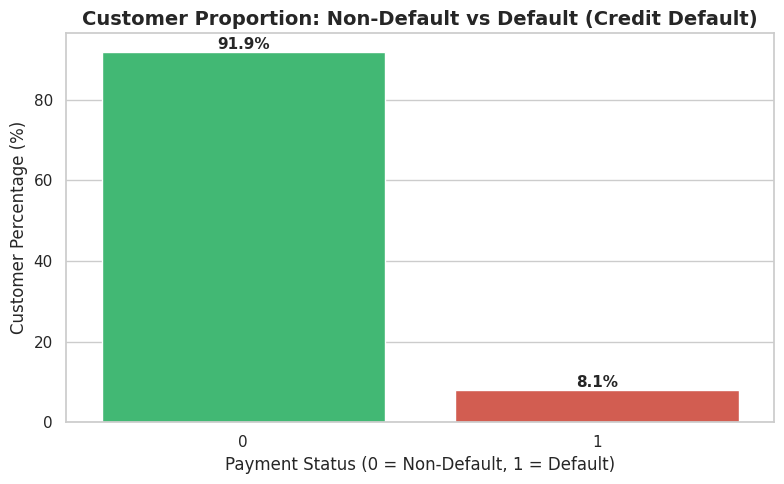

In [11]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set visual theme so the charts look professional (similar to business presentations)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Starting data visualization...\n")

df['AGE_YEARS'] = df['DAYS_BIRTH'] / 365

# ==============================================================================
# VISUALIZATION 1: Target Proportion (Non-Default vs Default)
# ==============================================================================
plt.figure(figsize=(8, 5))

# Calculate percentage
target_counts = df['TARGET'].value_counts(normalize=True) * 100

ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Proportion: Non-Default vs Default (Credit Default)', fontsize=14, fontweight='bold')
plt.xlabel('Payment Status (0 = Non-Default, 1 = Default)', fontsize=12)
plt.ylabel('Customer Percentage (%)', fontsize=12)

# Add percentage values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_12889/3926318094.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby('AGE_GROUP')['TARGET'].mean() * 100


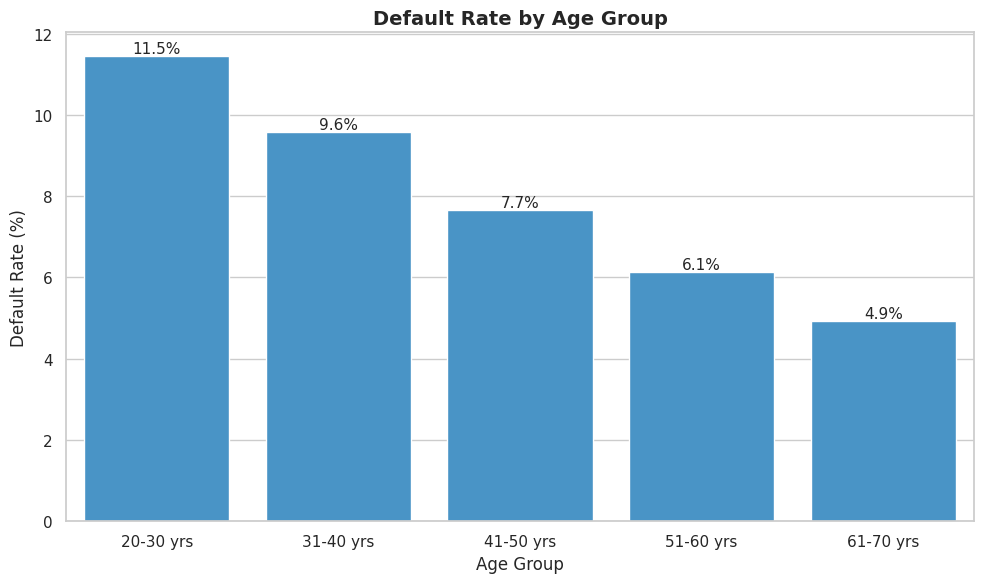

In [12]:
# ==============================================================================
# VISUALIZATION 2: Default Risk by Age Group
# ==============================================================================
plt.figure(figsize=(10, 6))

# Create age group categories (Binning)
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70],
                         labels=['20-30 yrs', '31-40 yrs', '41-50 yrs', '51-60 yrs', '61-70 yrs'])

# Calculate average TARGET (equivalent to Default Rate / Percentage of Default)
age_default = df.groupby('AGE_GROUP')['TARGET'].mean() * 100

ax2 = sns.barplot(x=age_default.index, y=age_default.values, color='#3498db')
plt.title('Default Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipykernel_12889/4021479729.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(y=occ_default.index, x=occ_default.values, palette='Reds_r')


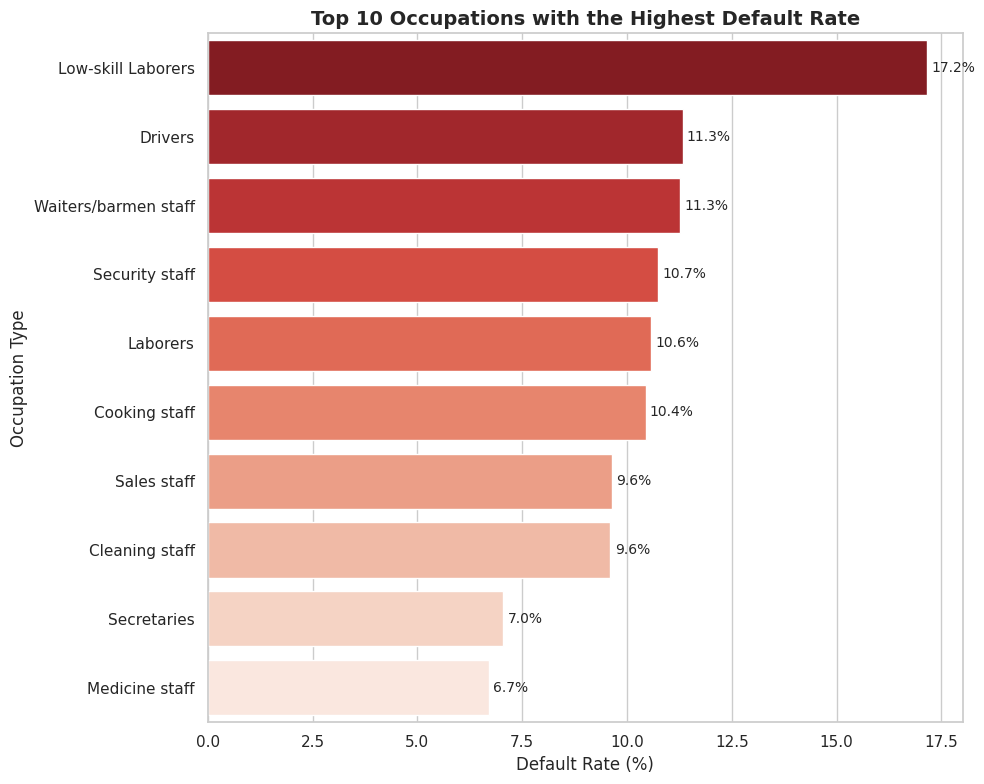


Visualization completed!


In [13]:
# ==============================================================================
# VISUALIZATION 3: Top 10 Occupations with the Highest Default Rate
# ==============================================================================
plt.figure(figsize=(10, 8))

# Calculate default rate per occupation, filter occupations with minimum 1000 samples for validity
occ_counts = df['OCCUPATION_TYPE'].value_counts()
valid_occ = occ_counts[occ_counts > 1000].index

occ_default = df[df['OCCUPATION_TYPE'].isin(valid_occ)].groupby('OCCUPATION_TYPE')['TARGET'].mean() * 100
occ_default = occ_default.sort_values(ascending=False).head(10)  # Take top 10 highest

ax3 = sns.barplot(y=occ_default.index, x=occ_default.values, palette='Reds_r')
plt.title('Top 10 Occupations with the Highest Default Rate', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Occupation Type', fontsize=12)

# Add percentage labels on the right side of bars
for p in ax3.patches:
    ax3.annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.1, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Drop AGE_GROUP column to avoid interference with the ML model
print("\nVisualization completed!")

In [14]:
# ==============================================================================
# 1. FEATURE ENGINEERING (Creating Combined Features)
# ==============================================================================
# Create new features directly in the dataframe df
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df['EXT_SOURCE_MIN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
df['EXT_SOURCE_MAX'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

print("[1] Merge feature successfully created (MEAN, MIN, MAX, PROD).\n")

[1] Merge feature successfully created (MEAN, MIN, MAX, PROD).



In [15]:
# ==============================================================================
# 2. MATHEMATICAL CORRELATION ANALYSIS
# ==============================================================================
ext_cols = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
            'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_PROD']

# Calculate correlation specifically for these columns
corr_matrix = df[ext_cols].corr()

# Extract correlations of these features with the TARGET column
target_corr = corr_matrix['TARGET'].sort_values()

print("📊 CORRELATION WITH DEFAULT RISK (TARGET) 📊")
print(target_corr)
print("-" * 50)
print("Note: Negative (-) values indicate an inverse relationship.")
print("The HIGHER the external score, the LOWER the default risk.\n")

📊 CORRELATION WITH DEFAULT RISK (TARGET) 📊
EXT_SOURCE_MEAN   -0.220840
EXT_SOURCE_MIN    -0.192750
EXT_SOURCE_PROD   -0.189605
EXT_SOURCE_MAX    -0.174193
EXT_SOURCE_2      -0.160295
EXT_SOURCE_3      -0.155892
EXT_SOURCE_1      -0.098887
TARGET             1.000000
Name: TARGET, dtype: float64
--------------------------------------------------
Note: Negative (-) values indicate an inverse relationship.
The HIGHER the external score, the LOWER the default risk.



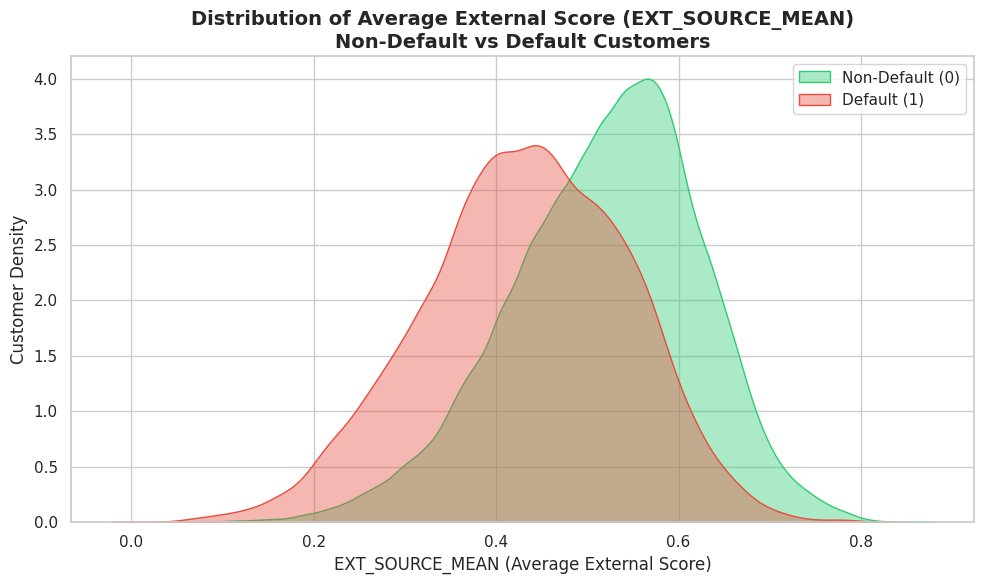

In [16]:
# ==============================================================================
# 3. DISTRIBUTION VISUALIZATION (KDE PLOT) FOR PRESENTATION SLIDES
# ==============================================================================
plt.figure(figsize=(10, 6))

# Create density distribution curves (KDE) to compare both groups
sns.kdeplot(df.loc[df['TARGET'] == 0, 'EXT_SOURCE_MEAN'], label='Non-Default (0)', color='#2ecc71', fill=True, alpha=0.4)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'EXT_SOURCE_MEAN'], label='Default (1)', color='#e74c3c', fill=True, alpha=0.4)

plt.title('Distribution of Average External Score (EXT_SOURCE_MEAN)\nNon-Default vs Default Customers', fontsize=14, fontweight='bold')
plt.xlabel('EXT_SOURCE_MEAN (Average External Score)', fontsize=12)
plt.ylabel('Customer Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## DATA TRAINING FOR LOGISTIC REGRESSION

In [17]:
# Import Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Starting the Logistic Regression modeling process...\n")

Starting the Logistic Regression modeling process...



In [18]:
# ==============================================================================
# 1. FEATURE PREPARATION (ENCODING)
# ==============================================================================
print("[1] Performing One-Hot Encoding on categorical columns...")
# Remove ID column since it is not useful for prediction
df_model = df.drop(columns=['SK_ID_CURR'])

# Convert all categorical/text columns into binary columns (1/0)
# drop_first=True is used to avoid the multicollinearity trap
df_encoded = pd.get_dummies(df_model, drop_first=True)
print(f"    -> Number of features after encoding: {df_encoded.shape[1] - 1} columns\n")

[1] Performing One-Hot Encoding on categorical columns...
    -> Number of features after encoding: 267 columns



In [19]:
# ==============================================================================
# 2. DATA SPLITTING (TRAIN & TEST)
# ==============================================================================
print("[2] Splitting data into Training (80%) and Testing (20%)...")
X = df_encoded.drop(columns=['TARGET'])
y = df_encoded['TARGET']

# stratify=y ensures the 8% default proportion is preserved in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"    -> Training Data: {X_train.shape[0]} rows")
print(f"    -> Testing Data: {X_test.shape[0]} rows\n")

[2] Splitting data into Training (80%) and Testing (20%)...
    -> Training Data: 246008 rows
    -> Testing Data: 61503 rows



In [20]:
# ==============================================================================
# 3. FEATURE SCALING (STANDARDIZATION)
# ==============================================================================
print("[3] Performing Data Scaling (Standardization)...")
scaler = StandardScaler()

# The model learns and fits the scale only from the Training data
X_train_scaled = scaler.fit_transform(X_train)
# The Testing data is only transformed using the Training scale (to prevent data leakage)
X_test_scaled = scaler.transform(X_test)
print("    -> Scaling completed.\n")

[3] Performing Data Scaling (Standardization)...
    -> Scaling completed.



In [21]:
# ==============================================================================
# 4. LOGISTIC REGRESSION MODEL TRAINING
# ==============================================================================
print("[4] Training Logistic Regression Model...")
# class_weight='balanced' is VERY IMPORTANT to handle imbalanced data (8% vs 92%)
logreg_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)
print("    -> Model training completed!\n")

[4] Training Logistic Regression Model...
    -> Model training completed!



In [22]:
# ==============================================================================
# 5. MAKING PREDICTIONS ON TEST DATA (TEST SET)
# ==============================================================================
print("[5] Making Predictions...")

# 1. Predict probability (0.0 to 1.0) for class 1 (Default)
# We take [:, 1] because we only need the probability of the customer defaulting
y_pred_proba = logreg_model.predict_proba(X_test_scaled)[:, 1]

# 2. Predict binary label (Directly predicts 0 or 1 based on default threshold)
y_pred = logreg_model.predict(X_test_scaled)

print("    -> Prediction completed! Variables y_pred_proba and y_pred have been created.\n")

[5] Making Predictions...
    -> Prediction completed! Variables y_pred_proba and y_pred have been created.



In [23]:
# ==============================================================================
# 5. MODEL EVALUATION
# ==============================================================================
print("[5] Evaluating the Model on Test Data...")

# Predict probabilities (What is the % chance of default?)
y_pred_proba = logreg_model.predict_proba(X_test_scaled)[:, 1]
# Predict final class (1 or 0)
y_pred = logreg_model.predict(X_test_scaled)

# Calculate main metric: ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🌟 ROC-AUC SCORE: {roc_auc:.4f} 🌟")
print("The closer to 1.0, the better the model.\n")

# Display Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

[5] Evaluating the Model on Test Data...

🌟 ROC-AUC SCORE: 0.7506 🌟
The closer to 1.0, the better the model.

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



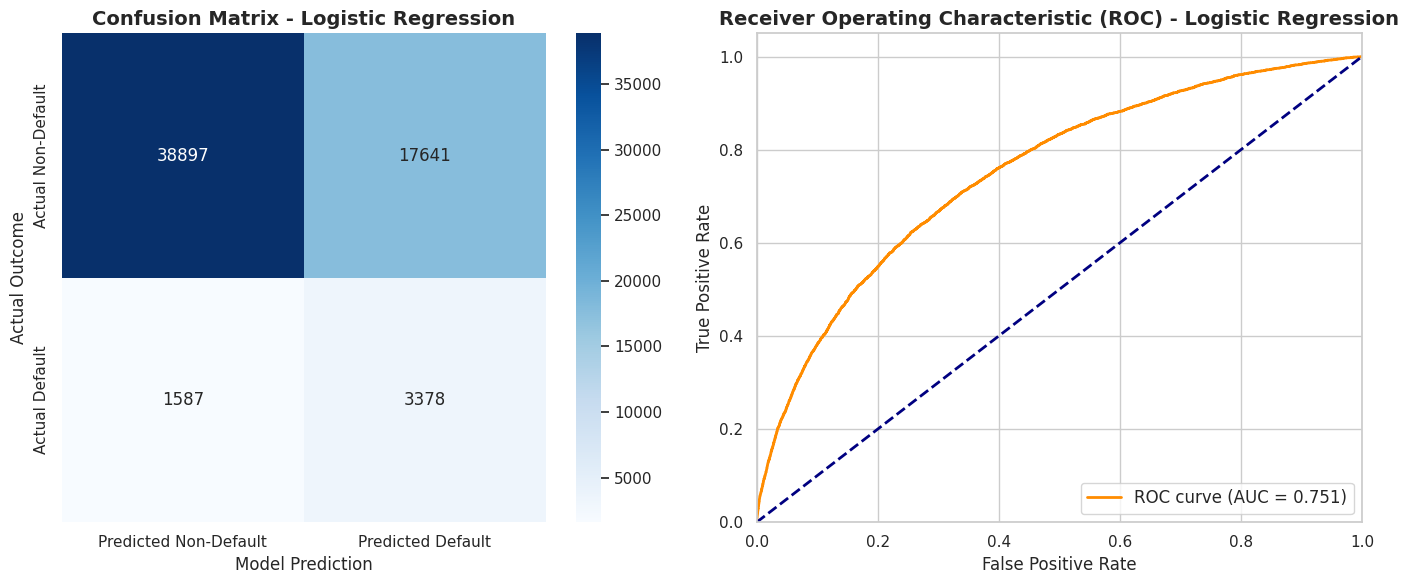

In [24]:
# ==============================================================================
# 6. EVALUATION VISUALIZATION (FOR PRESENTATION SLIDES)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Non-Default', 'Predicted Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model Prediction')
axes[0].set_ylabel('Actual Outcome')

# B. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic (ROC) - Logistic Regression', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

## DATA TRAINING FOR LightGBM

In [25]:
# Import LightGBM library
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Starting LightGBM model training...\n")

🚀 Starting LightGBM model training...



In [26]:
# ==============================================================================
# 1. MODEL INITIALIZATION AND TRAINING
# ==============================================================================
# is_unbalance=True is LightGBM’s built-in parameter for handling class imbalance
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,        # Build 500 decision trees
    learning_rate=0.05,      # Learning rate (how fast the model learns from errors)
    max_depth=7,             # Prevent trees from becoming too complex (avoid overfitting)
    is_unbalance=True,       # Key parameter for handling ~8% default rate
    random_state=42,
    n_jobs=-1                # Use all CPU cores for faster processing
)

print("[1] Training the model... (This may take 1–2 minutes)")
# Directly use X_train_scaled from the previous Logistic Regression step
lgb_model.fit(X_train_scaled, y_train)
print("    -> LightGBM training completed!\n")

[1] Training the model... (This may take 1–2 minutes)
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.406769 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10288
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 255
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
    -> LightGBM training completed!



In [27]:
# ==============================================================================
# 2. PREDICTION AND EVALUATION
# ==============================================================================
print("[2] Performing Prediction and Metric Evaluation...")
# Use new variable names to avoid conflict with Logistic Regression
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_lgb = lgb_model.predict(X_test_scaled)

# Calculate metrics to support business justification
roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
pr_auc_lgb = average_precision_score(y_test, y_pred_proba_lgb)

print(f"\n🌟 ROC-AUC SCORE (LightGBM) : {roc_auc_lgb:.4f}")
print(f"🎯 PR-AUC SCORE  (LightGBM) : {pr_auc_lgb:.4f}\n")

print("=== CLASSIFICATION REPORT (LightGBM) ===")
print(classification_report(y_test, y_pred_lgb))

[2] Performing Prediction and Metric Evaluation...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🌟 ROC-AUC SCORE (LightGBM) : 0.7598
🎯 PR-AUC SCORE  (LightGBM) : 0.2510

=== CLASSIFICATION REPORT (LightGBM) ===
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.17      0.66      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.72      0.78     61503



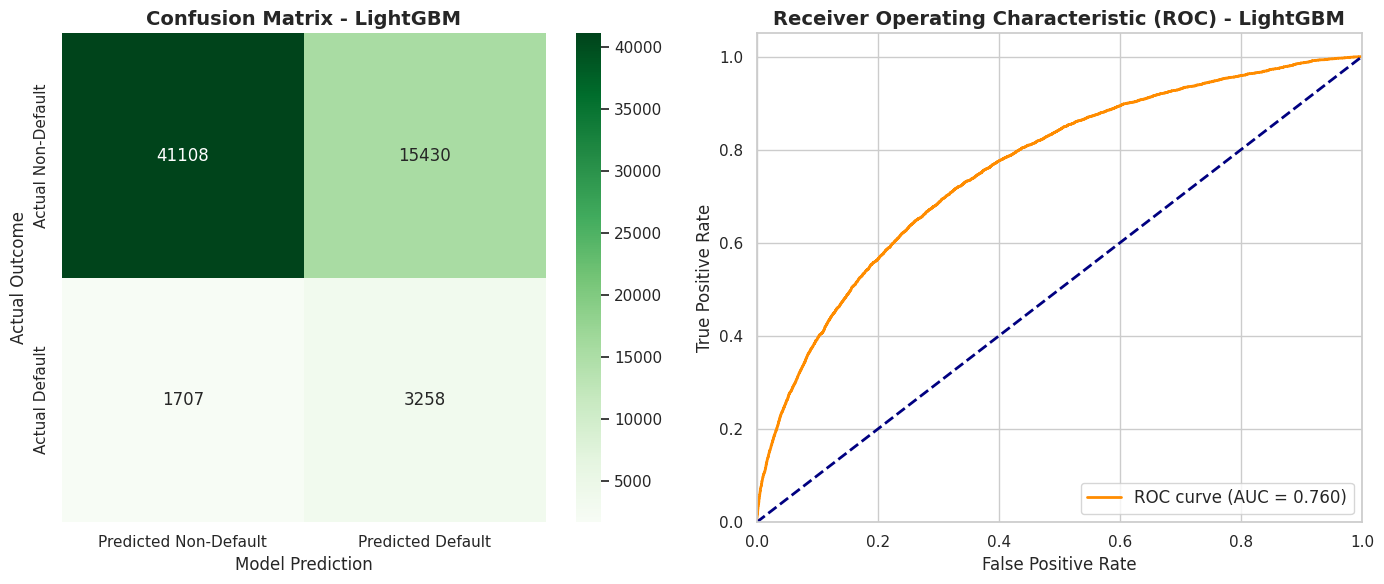

In [28]:
# ==============================================================================
# 3. LIGHTGBM EVALUATION VISUALIZATION (FOR PRESENTATION SLIDES)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# A. Confusion Matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Predicted Non-Default', 'Predicted Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'])
axes[0].set_title('Confusion Matrix - LightGBM', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model Prediction')
axes[0].set_ylabel('Actual Outcome')

# B. ROC Curve
# Ensure y_pred_proba_lgb and roc_auc_lgb have been executed in the previous prediction step
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_pred_proba_lgb)
axes[1].plot(fpr_lgb, tpr_lgb, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lgb:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic (ROC) - LightGBM', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

## FEATURE OF IMPORTANCE

🔍 Analyzing Feature Importance from the LightGBM model...



/tmp/ipykernel_12889/1126949209.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')


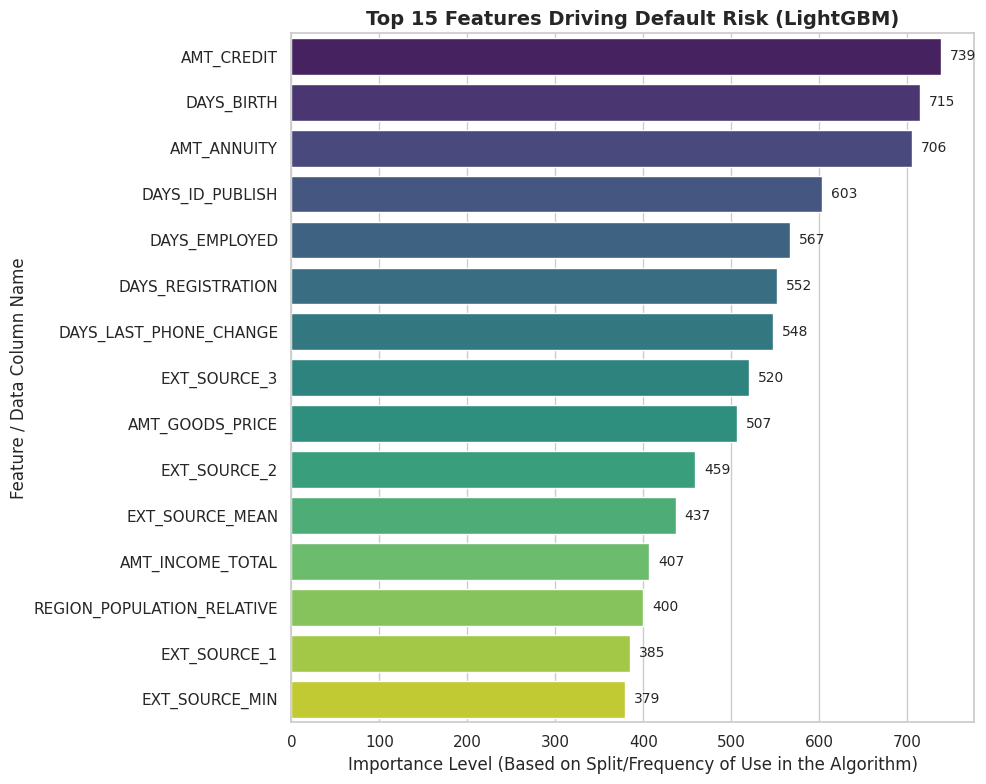

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Analyzing Feature Importance from the LightGBM model...\n")

# 1. Retrieve feature names (columns) from the original dataset X
# (X is the variable from the previous Data Splitting stage)
feature_names = X.columns

# 2. Retrieve 'importance' scores generated by LightGBM
importances = lgb_model.feature_importances_

# 3. Combine into a DataFrame for easier sorting
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort the data and take the top 15 features
top_15_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)

# ==============================================================================
# 5. CREATE VISUALIZATION
# ==============================================================================
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')

plt.title('Top 15 Features Driving Default Risk (LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Level (Based on Split/Frequency of Use in the Algorithm)', fontsize=12)
plt.ylabel('Feature / Data Column Name', fontsize=12)

# Add values at the end of each bar for clarity
for index, value in enumerate(top_15_features['Importance']):
    plt.text(value + 10, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

🔍 Analyzing Feature Importance (Based on GAIN) from the LightGBM model...



/tmp/ipykernel_12889/588581409.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gain_Importance', y='Feature', data=top_15_features, palette='magma')


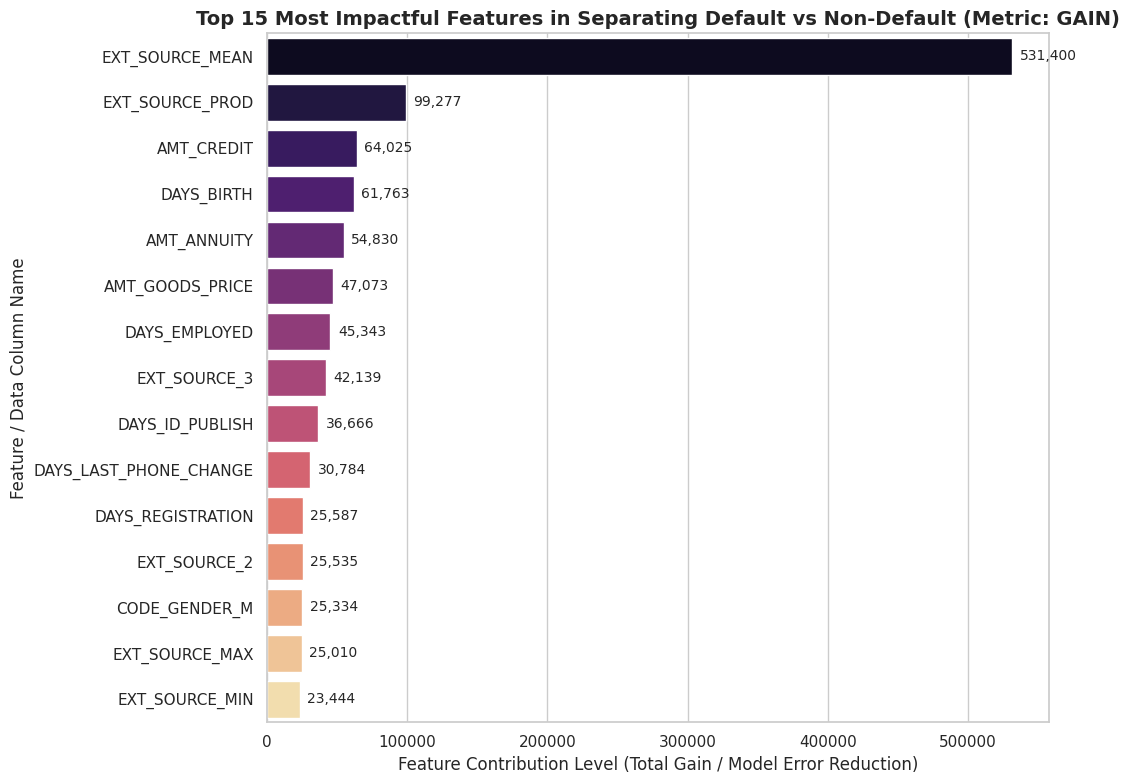

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Analyzing Feature Importance (Based on GAIN) from the LightGBM model...\n")

# 1. Retrieve feature names (columns) from dataset X
feature_names = X.columns

# ==============================================================================
# 2. KEY CHANGE: Using importance_type='gain'
# Gain measures the QUALITY/IMPACT of features, not how frequently they are used.
# This is crucial for imbalanced datasets.
# ==============================================================================
importances_gain = lgb_model.booster_.feature_importance(importance_type='gain')

# 3. Combine into a DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Gain_Importance': importances_gain
})

# 4. Sort data and take top 15 features
top_15_features = feature_imp_df.sort_values(by='Gain_Importance', ascending=False).head(15)

# ==============================================================================
# 5. CREATE VISUALIZATION
# ==============================================================================
plt.figure(figsize=(11, 8))  # Slightly wider to avoid text cutoff

# Use a different color palette (e.g., 'flare' or 'magma') to emphasize
# that this is a more advanced metric than a standard barplot
sns.barplot(x='Gain_Importance', y='Feature', data=top_15_features, palette='magma')

# Title and labels adjusted to "Gain" context
plt.title('Top 15 Most Impactful Features in Separating Default vs Non-Default (Metric: GAIN)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Contribution Level (Total Gain / Model Error Reduction)', fontsize=12)
plt.ylabel('Feature / Data Column Name', fontsize=12)

# Add values at the end of each bar (formatted with thousand separators
# since Gain values are typically large numbers)
max_val = top_15_features['Gain_Importance'].max()
for index, value in enumerate(top_15_features['Gain_Importance']):
    plt.text(value + (max_val * 0.01), index, f"{value:,.0f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

print("🧪 STARTING EXPERIMENT: GAIN vs SPLIT")

# 1. Get Top 15 Features based on SPLIT
importances_split = lgb_model.booster_.feature_importance(importance_type='split')
top_15_split = X.columns[np.argsort(importances_split)[::-1][:15]]

# 2. Get Top 15 Features based on GAIN
importances_gain = lgb_model.booster_.feature_importance(importance_type='gain')
top_15_gain = X.columns[np.argsort(importances_gain)[::-1][:15]]

# 3. Prepare Training and Testing Data that ONLY contain those Top 15 Features
X_train_split, X_test_split = X_train[top_15_split], X_test[top_15_split]
X_train_gain, X_test_gain = X_train[top_15_gain], X_test[top_15_gain]

# 4. Define identical LightGBM parameters for a fair comparison
params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 7,
    'class_weight': 'balanced',  # Or is_unbalance=True based on your previous code
    'random_state': 42,
    'n_jobs': -1
}

# 5. Train Model A (Using only features from SPLIT)
print("-> Training Model A (Top 15 SPLIT Features)...")
model_split = lgb.LGBMClassifier(**params)
model_split.fit(X_train_split, y_train)
y_pred_proba_split = model_split.predict_proba(X_test_split)[:, 1]
roc_auc_split = roc_auc_score(y_test, y_pred_proba_split)

# 6. Train Model B (Using only features from GAIN)
print("-> Training Model B (Top 15 GAIN Features)...")
model_gain = lgb.LGBMClassifier(**params)
model_gain.fit(X_train_gain, y_train)
y_pred_proba_gain = model_gain.predict_proba(X_test_gain)[:, 1]
roc_auc_gain = roc_auc_score(y_test, y_pred_proba_gain)

# 7. Display Comparison Results
print("\n" + "="*50)
print("🏆 PREDICTION COMPARISON RESULTS (ROC-AUC SCORE)")
print("="*50)
print(f"Model A (Using Top 15 SPLIT Features) : {roc_auc_split:.4f}")
print(f"Model B (Using Top 15 GAIN Features)  : {roc_auc_gain:.4f}")
print("="*50)

if roc_auc_gain > roc_auc_split:
    print("\n✅ CONCLUSION: PROVEN! The GAIN metric successfully selects features that produce more accurate predictions compared to the SPLIT metric.")
else:
    print("\n⚠️ CONCLUSION: The results are comparable or SPLIT performs slightly better on this dataset (this is relatively rare for imbalanced data).")

🧪 STARTING EXPERIMENT: GAIN vs SPLIT
-> Training Model A (Top 15 SPLIT Features)...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040867 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3589
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
-> Training Model B (Top 15 GAIN Features)...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3565
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 15
[LightGBM] [